### Task 3

In [48]:
from sklearn.datasets import make_moons
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import torch
from torch import nn as nn, optim
from torch import sqrt, exp
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt


from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB',
                                                '#E55934', '#FA7921'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'


In [49]:
# testing the training loop
digits = load_digits()
X = digits.data          # shape (1797, 64)
y = digits.target        # labels 0–9

# Convert to tensor
X = torch.tensor(X, dtype=torch.float32)

# Train–test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
class AE(nn.Module):
    def __init__(self, input_size, bottleneck_size, hidden_size, layers=1):
        '''
        Init defines the layers of the network
        First task input dim =2, 
        bottleneck dim =1, 
        layers is the number of hidden layers
        '''
        super().__init__() # required for nn.Module 
        self.input_size = input_size
        self.bottleneck_size = bottleneck_size
        self.hidden_size = hidden_size #hyperparameter
        self.layers = layers # hyperparameter
        # save results
        self.train_losses = []
        self.test_losses = []
        self.outputs = []

        # Encoder
        '''
        make moons has 2 dim, encoder squeezes to 1 dim
             Layers: - linear layers: y =Wx + b, W is weights, b is bias
             ReLU activation: not a Layer but an opperatin applied after linear layer.
                              ReLU(x) = max(0,x), one linear function, before this, we can't learn 
                              complicated shapes (make_moons), now ReLu adds nonlinearity to learn
                              non- straight shapes
        for loop: go through number of layers, add linear + ReLU each time
        after all layers; add final linear layer the bottleneck layer, which is linear, so no ReLU after
        Sequential: package all layers into one object, in order

        general: input -> hidden layers (repeated layers times) -> bottleneck
        '''
        encoder_layers = []
        in_size = input_size
        for _ in range(layers):
            encoder_layers.append(nn.Linear(in_size, hidden_size))
            encoder_layers.append(nn.ReLU(inplace=True))
            in_size = hidden_size #we choose this in the beginning
        encoder_layers.append(nn.Linear(hidden_size, bottleneck_size)) 
        self.encoder = nn.Sequential(*encoder_layers)

        #decoder
        '''
        reverse of encoder
        general: bottleneck -> hidden layers (repeated layers times) -> output
        '''
        decoder_layers = []
        in_size = bottleneck_size
        for _ in range(layers):
            decoder_layers.append(nn.Linear(in_size, hidden_size))
            decoder_layers.append(nn.ReLU(inplace=True))
            in_size = hidden_size
        decoder_layers.append(nn.Linear(hidden_size, input_size))
        self.decoder = nn.Sequential(*decoder_layers)    

    def forward(self, x):
        '''
        forward defines the forward pass of the network
        reconstructed 2D points from input 2D points
        '''
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def train_autoencoder(self, X_train, training_set_size, epochs, mini_batch_size, mmd_kernel, mmd_bandwidth, lambda_mmd, learning_rate=1e-3):
    
        '''
        model: AE instance
        data: input data to train on
        epochs: number of passes through the dataset
        batch_size: number of samples per gradient update
        learning_rate: step size for optimizer
        '''
        # Loss function: Mean Squared Error (MSE)
        loss_function = nn.MSELoss()
        # Optimizer: Adam
        optimizer = optim.Adam(self.parameters(), lr=learning_rate)

        # Use Data loader for mini-batches, use taining_set_size to select subset of data
        loader = torch.utils.data.DataLoader(X_train[:training_set_size], batch_size=mini_batch_size, shuffle=True)

        # Training loop
        for epoch in tqdm(range(epochs)):
            for X_batch in loader:
                #print(X_batch)
                # Make forward pass
                decoded = self.forward(X_batch)
                # Compute loss
                loss = loss_function(decoded, X_batch)
                # Compute zero-grad
                optimizer.zero_grad()
                # Backprop
                loss.backward()
                # Step
                optimizer.step()
                # Save losses
                self.train_losses.append(loss.item())
            # Save outputs for later
            self.outputs.append((epoch, X_batch, decoded))
        return self
    
    # Loss function MMD^2
    def compute_mmd(self, X_train, h = 1, kernel = "squared_exponential"):
        N = X_train.shape[0]
        # Sample from standard normal
        Z = torch.randn((N, self.bottleneck_size))
        # Get codes from encoder
        codes = X_train
        for layer in self.encoder:
            codes = layer(codes)
        # Calculate distance matrices (vectorized)
        D_XX = self.calculate_distance_matrix(codes, codes)
        D_XZ = self.calculate_distance_matrix(codes, Z)
        D_ZZ = self.calculate_distance_matrix(Z, Z)
        # Calculate kernels
        if kernel == "squared_exponential":
            K_XX = self.squared_exponential(D_XX, h)
            K_XZ = self.squared_exponential(D_XZ, h)
            K_ZZ = self.squared_exponential(D_ZZ, h)
        elif kernel == "inverse_multi_quadratic":
            K_XX = self.inverse_multi_quadratic(D_XX, h)
            K_XZ = self.inverse_multi_quadratic(D_XZ, h)
            K_ZZ = self.inverse_multi_quadratic(D_ZZ, h)
        # Compute MMD^2
        mmd_sq = (torch.sum(K_XX) - torch.trace(K_XX)) / (N * (N - 1)) + \
                (torch.sum(K_ZZ) - torch.trace(K_ZZ)) / (N * (N - 1)) - \
                2 * torch.sum(K_XZ) / (N * N)

        return mmd_sq
    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = torch.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = torch.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
    
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   

    def inverse_multi_quadratic(self, D_AB, h):
        # epsilon for numerical stability
        epsilon = 1e-8
        return 1 / sqrt(1 + D_AB / (h ** 2) + epsilon)

        
 

## 1. Investigate different hyperparameters

In Ex. 1 we saw that the hyperparameters that have the biggest influence are network size and depth, mini-batch size and training time/epochs. So we will only investigate these.

In [ ]:
# Test different 
hyperparameters_tss = [
    (200, 32, 20, 0.001, 32, 2),    # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
    (500, 32, 20, 0.001, 32, 2),
    (1000, 32, 20, 0.001, 32, 2),
    (1500, 32, 20, 0.001, 32, 2)
]

results_tss = []

for params in hyperparameters_tss:
    training_set_size, batch_size, n_epochs, lr, hidden_size, layers = params
    
    print(f"Training with training set size: {training_set_size}")

    model_tss = AE(
        input_size=64,
        bottleneck_size=10,
        hidden_size=hidden_size,
        layers=layers
    )

    model_tss.train_autoencoder(X_train,
                                training_set_size=training_set_size,
                                epochs=n_epochs,
                                mini_batch_size=batch_size,
                                mmd_kernel="squared_exponential",   # default choice
                                mmd_bandwidth=1.0,                  # reasonable default
                                lambda_mmd=0.0,                     # 0 means "no MMD regularization"
                                learning_rate=lr
)

    results_tss.append((params, model_tss.train_losses, model_tss.outputs[-1]))


Training with training set size: 200


100%|██████████| 20/20 [00:00<00:00, 60.89it/s]


Training with training set size: 500


100%|██████████| 20/20 [00:00<00:00, 38.60it/s]


Training with training set size: 1000


100%|██████████| 20/20 [00:01<00:00, 19.03it/s]


Training with training set size: 1500


100%|██████████| 20/20 [00:01<00:00, 14.32it/s]


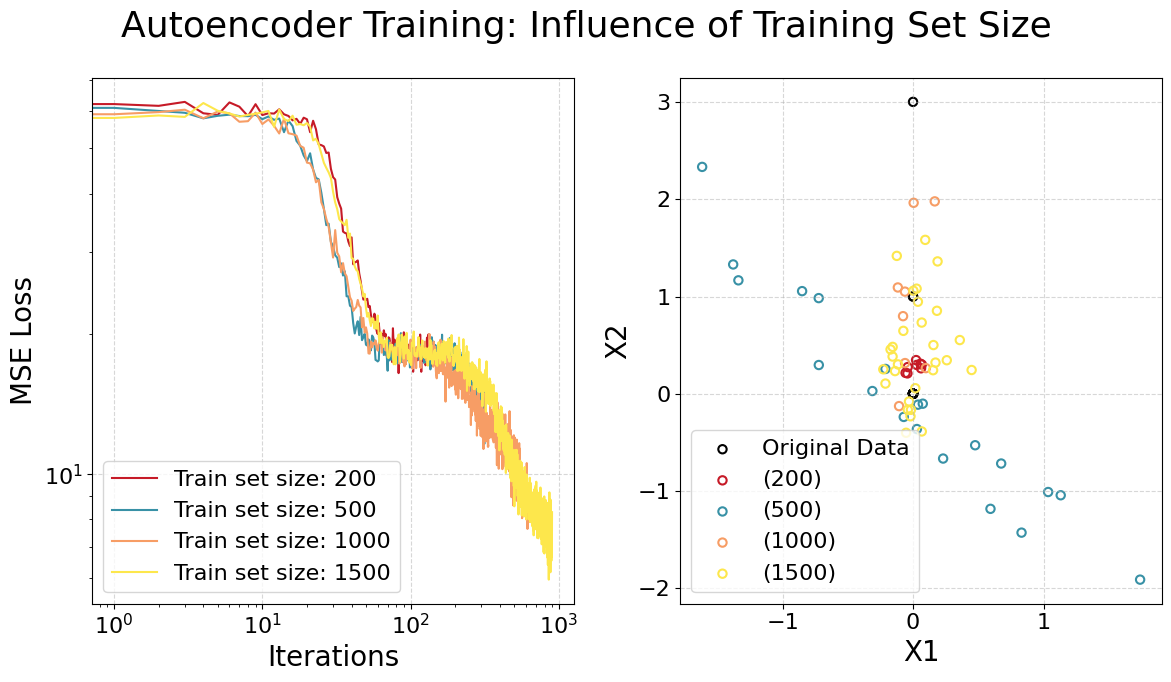

In [51]:
# Plot MSE loss for different training set sizes
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Training Set Size", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Train set size: {params[0]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
#axes[0].set_title("MSE Loss vs Iterations for different Training Set Sizes")
axes[0].legend()
axes[0].loglog()
# Plot final reconstruction

# Get final output
final_epoch, X_batch, decoded = model_tss.outputs[-1]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"({results_tss[i][0][0]})", 
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
#axes[1].set_title("Final Reconstruction for different Training Set Sizes")
axes[1].legend()
plt.tight_layout()
plt.show()

In [57]:
# Differences in number of epochs
hyperparameters_tss = [
    (200, 32, 20, 0.001, 32, 2),    # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
    (200, 32, 200, 0.001, 32, 2),
    (200, 32, 2000, 0.001, 32, 2),
    (200, 32, 5000, 0.001, 32, 2)
]

results_tss = []

for params in hyperparameters_tss:
    training_set_size, batch_size, n_epochs, lr, hidden_size, layers = params
    
    print(f"Training with epoch number: {n_epochs}")

    model_tss = AE(
        input_size=64,
        bottleneck_size=10,
        hidden_size=hidden_size,
        layers=layers
    )

    model_tss.train_autoencoder(X_train,
                                training_set_size=training_set_size,
                                epochs=n_epochs,
                                mini_batch_size=batch_size,
                                mmd_kernel="squared_exponential",   # default choice
                                mmd_bandwidth=1.0,                  # reasonable default
                                lambda_mmd=0.0,                     # 0 means "no MMD regularization"
                                learning_rate=lr
)

    results_tss.append((params, model_tss.train_losses, model_tss.outputs[-1]))


Training with epoch number: 20


100%|██████████| 20/20 [00:00<00:00, 81.52it/s]


Training with epoch number: 200


100%|██████████| 200/200 [00:02<00:00, 84.37it/s]


Training with epoch number: 2000


100%|██████████| 2000/2000 [00:23<00:00, 85.38it/s] 


Training with epoch number: 5000


100%|██████████| 5000/5000 [00:59<00:00, 84.65it/s]


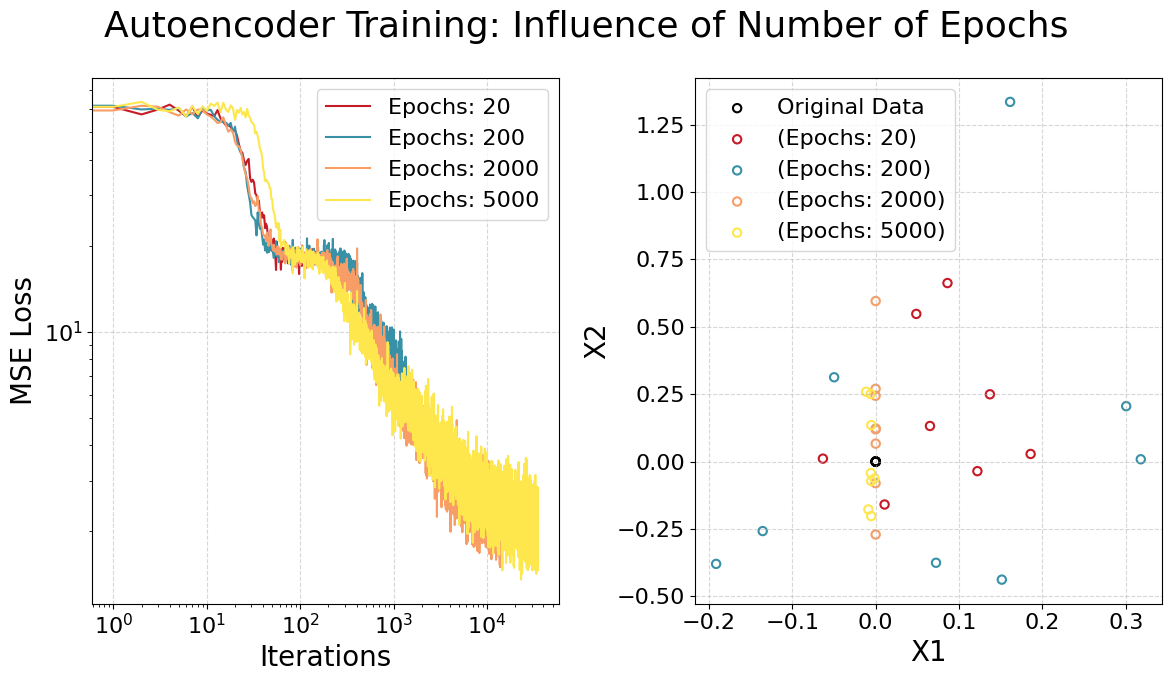

In [54]:
# Plot MSE loss for different number of epochs
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Number of Epochs", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Epochs: {params[2]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_tss[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epochs: {results_tss[i][0][2]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

In [58]:
# Differences in mini-batch sizes
hyperparameters_tss = [
    (200, 32, 20, 0.001, 32, 2),    # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
    (200, 64, 20, 0.001, 32, 2),
    (200, 128, 20, 0.001, 32, 2),
    (200, 256, 20, 0.001, 32, 2)
]

results_tss = []

for params in hyperparameters_tss:
    training_set_size, batch_size, n_epochs, lr, hidden_size, layers = params
    
    print(f"Training with mini batch size: {batch_size}")

    model_tss = AE(
        input_size=64,
        bottleneck_size=10,
        hidden_size=hidden_size,
        layers=layers
    )

    model_tss.train_autoencoder(X_train,
                                training_set_size=training_set_size,
                                epochs=n_epochs,
                                mini_batch_size=batch_size,
                                mmd_kernel="squared_exponential",   # default choice
                                mmd_bandwidth=1.0,                  # reasonable default
                                lambda_mmd=0.0,                     # 0 means "no MMD regularization"
                                learning_rate=lr
)

    results_tss.append((params, model_tss.train_losses, model_tss.outputs[-1]))


Training with mini batch size: 32


100%|██████████| 20/20 [00:00<00:00, 89.56it/s]


Training with mini batch size: 64


100%|██████████| 20/20 [00:00<00:00, 136.44it/s]


Training with mini batch size: 128


100%|██████████| 20/20 [00:00<00:00, 179.18it/s]


Training with mini batch size: 256


100%|██████████| 20/20 [00:00<00:00, 374.20it/s]


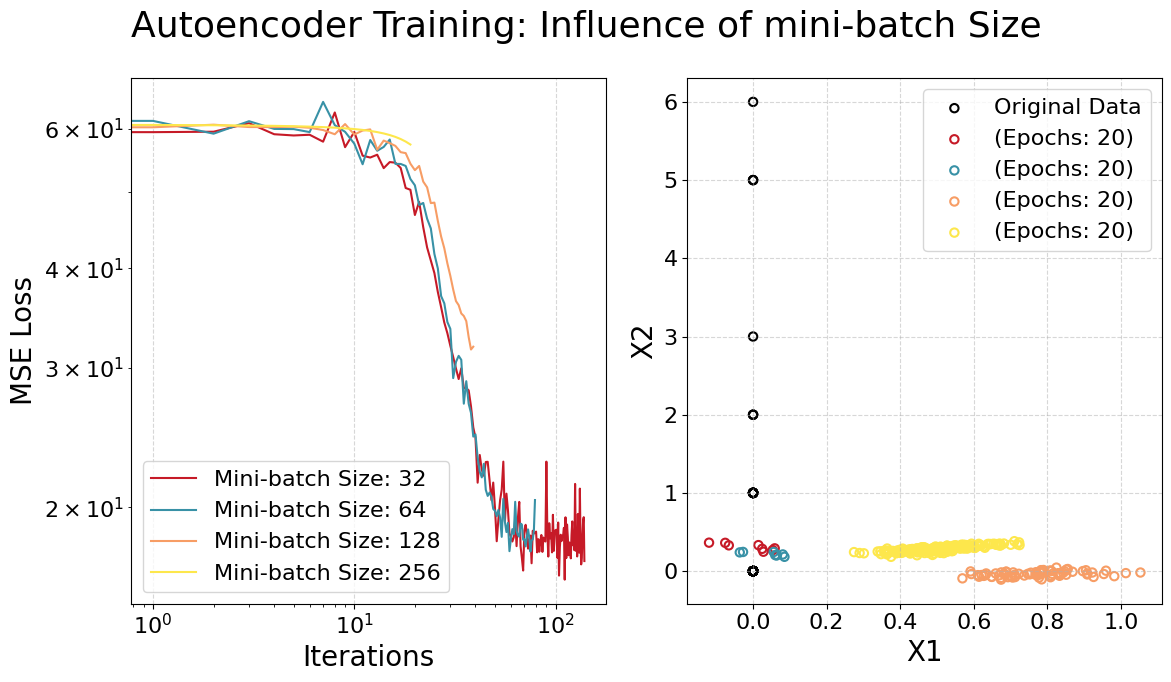

In [59]:
# Plot MSE loss for different number of epochs
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of mini-batch Size", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Mini-batch Size: {params[1]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_tss[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epochs: {results_tss[i][0][2]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

In [60]:
# Differences in network sizes
hyperparameters_tss = [
    (200, 128, 20, 0.001, 32, 2),    # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
    (200, 128, 20, 0.001, 32, 3),
    (200, 128, 20, 0.001, 32, 4),
    (200, 128, 20, 0.001, 32, 8)
]

results_tss = []

for params in hyperparameters_tss:
    training_set_size, batch_size, n_epochs, lr, hidden_size, layers = params
    
    print(f"Training with number of layers: {layers}")

    model_tss = AE(
        input_size=64,
        bottleneck_size=10,
        hidden_size=hidden_size,
        layers=layers
    )

    model_tss.train_autoencoder(X_train,
                                training_set_size=training_set_size,
                                epochs=n_epochs,
                                mini_batch_size=batch_size,
                                mmd_kernel="squared_exponential",   # default choice
                                mmd_bandwidth=1.0,                  # reasonable default
                                lambda_mmd=0.0,                     # 0 means "no MMD regularization"
                                learning_rate=lr
)

    results_tss.append((params, model_tss.train_losses, model_tss.outputs[-1]))


Training with number of layers: 2


100%|██████████| 20/20 [00:00<00:00, 87.18it/s]


Training with number of layers: 3


100%|██████████| 20/20 [00:00<00:00, 157.04it/s]


Training with number of layers: 4


100%|██████████| 20/20 [00:00<00:00, 137.36it/s]


Training with number of layers: 8


100%|██████████| 20/20 [00:00<00:00, 82.98it/s]


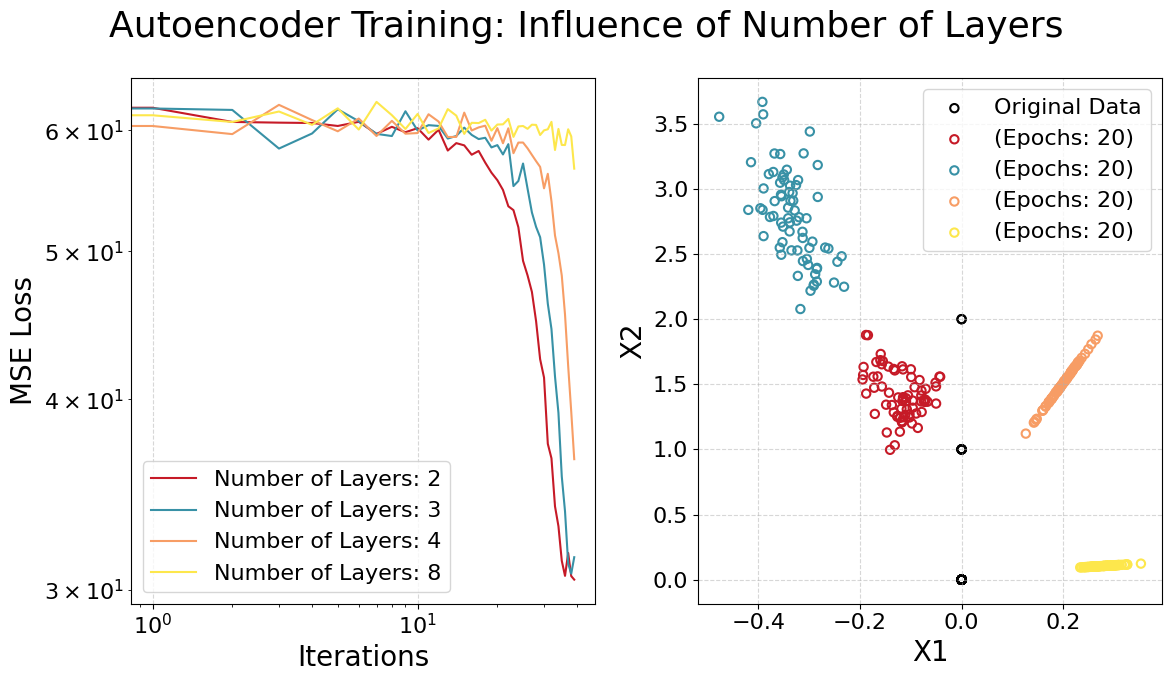

In [61]:
# Plot MSE loss for different number of epochs
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Number of Layers", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Number of Layers: {params[5]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_tss[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epochs: {results_tss[i][0][2]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()

In [62]:
# 1 Investigate the influence of mini-batch-size given fixed other hyperparameters
hyperparameters_tss = [
    (200, 32, 20, 0.001, 4, 2),    # training_set_size, mini_batch_size, n_epochs, lr, hidden_size, layers
    (200, 64, 20, 0.001, 4, 2),
    (200, 128, 20, 0.001, 4, 2),
    (200, 256, 20, 0.001, 4, 2)
]

results_tss = []

for params in hyperparameters_tss:
    training_set_size, batch_size, n_epochs, lr, hidden_size, layers = params
    
    print(f"Training with training set size: {params[0]}, n_epochs: {params[2]}, mini batch size: {params[1]}")

    model_tss = AE(
        input_size=64,
        bottleneck_size=10,
        hidden_size=hidden_size,
        layers=layers
    )

    model_tss.train_autoencoder(X_train,
                                training_set_size=training_set_size,
                                epochs=n_epochs,
                                mini_batch_size=batch_size,
                                mmd_kernel="squared_exponential",   # default choice
                                mmd_bandwidth=1.0,                  # reasonable default
                                lambda_mmd=0.0,                     # 0 means "no MMD regularization"
                                learning_rate=lr
)

    results_tss.append((params, model_tss.train_losses, model_tss.outputs[-1]))



Training with training set size: 200, n_epochs: 20, mini batch size: 32


100%|██████████| 20/20 [00:00<00:00, 86.96it/s]


Training with training set size: 200, n_epochs: 20, mini batch size: 64


100%|██████████| 20/20 [00:00<00:00, 140.36it/s]


Training with training set size: 200, n_epochs: 20, mini batch size: 128


100%|██████████| 20/20 [00:00<00:00, 137.52it/s]


Training with training set size: 200, n_epochs: 20, mini batch size: 256


100%|██████████| 20/20 [00:00<00:00, 326.61it/s]


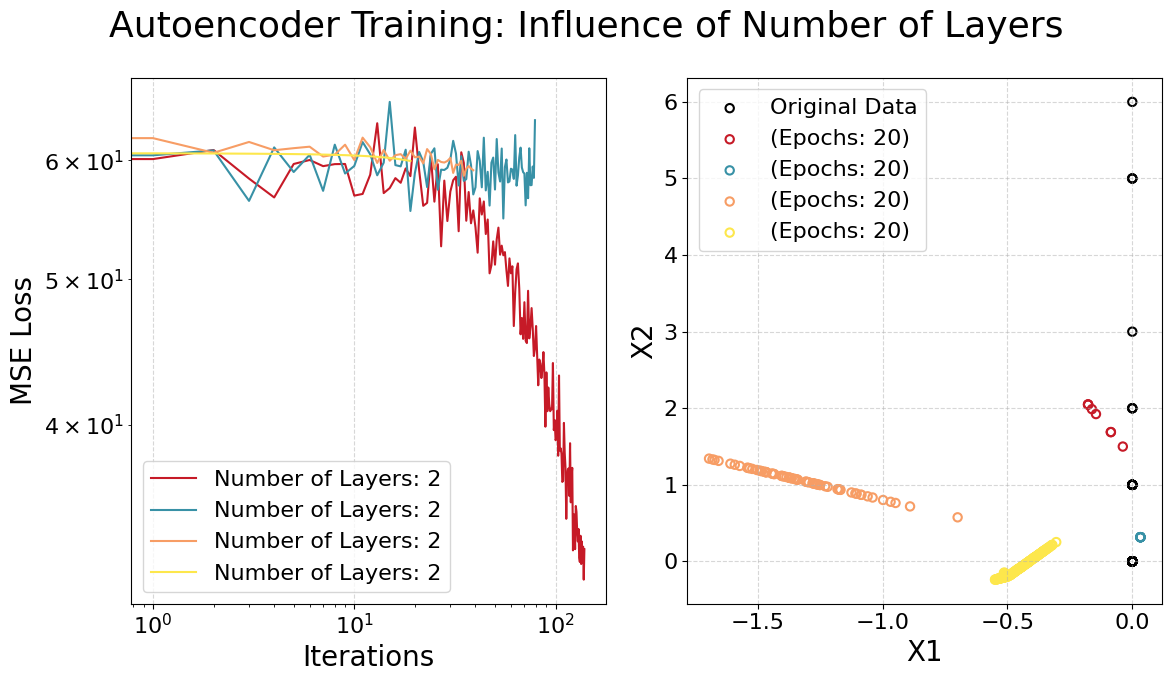

In [63]:
# Plot MSE loss for different number of epochs
fig, axes = plt.subplots(1, 2)
fig.suptitle("Autoencoder Training: Influence of Number of Layers", fontsize=26)
# Plot training losses
for res in results_tss:
    params, train_losses, _ = res
    axes[0].plot(train_losses, label=f"Number of Layers: {params[5]}")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("MSE Loss")
axes[0].loglog()
axes[0].legend()


# Plot final reconstruction
# Get final output
final_epoch, X_batch, decoded = results_tss[-1][2]
axes[1].scatter(X_batch[:,0].detach().numpy(), X_batch[:,1].detach().numpy(), 
                label="Original Data", 
                color = "black")
for i in range(len(results_tss)):
    final_epoch, X_batch, decoded = results_tss[i][2]
    axes[1].scatter(decoded[:,0].detach().numpy(), decoded[:,1].detach().numpy(), 
                    label=f"(Epochs: {results_tss[i][0][2]})", 
                    alpha=1,
                    color = colors[i])
axes[1].set_xlabel("X1")
axes[1].set_ylabel("X2")
axes[1].legend()
plt.tight_layout()
plt.show()